# Computer Vision Using Deep Learning - Practical 6 (ii)

## 1: Import Libraries

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## 2: Image Exploration and Chunking

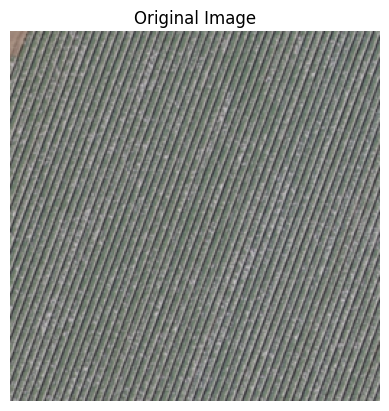

In [2]:
I = cv2.imread("TwoclassFE/agricultural07.tif")
plt.imshow(cv2.cvtColor(I, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off') # Hide axes
plt.show()

In [3]:
I.shape

(256, 256, 3)

In [4]:
chunks = []
chunk_size = 64
for i in range(0, I.shape[0], chunk_size):
    for j in range(0, I.shape[1], chunk_size):
        chunk = I[i:i+chunk_size, j:j+chunk_size]
        chunks.append(np.array(chunk))

print(f"Total chunks created: {len(chunks)}")
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1} shape: {chunk.shape}")

Total chunks created: 16
Chunk 1 shape: (64, 64, 3)
Chunk 2 shape: (64, 64, 3)
Chunk 3 shape: (64, 64, 3)
Chunk 4 shape: (64, 64, 3)
Chunk 5 shape: (64, 64, 3)
Chunk 6 shape: (64, 64, 3)
Chunk 7 shape: (64, 64, 3)
Chunk 8 shape: (64, 64, 3)
Chunk 9 shape: (64, 64, 3)
Chunk 10 shape: (64, 64, 3)
Chunk 11 shape: (64, 64, 3)
Chunk 12 shape: (64, 64, 3)
Chunk 13 shape: (64, 64, 3)
Chunk 14 shape: (64, 64, 3)
Chunk 15 shape: (64, 64, 3)
Chunk 16 shape: (64, 64, 3)


## 3: Feature Extraction and CSV Creation

1. Divides the image into a 4x4 grid (16 chunks).
2. For each chunk, it finds the most frequent pixel intensity (mode) for the Red, Green, and Blue channels.
3. These 3 values (R, G, B modes) per chunk result in 16 * 3 = 48 features for the entire image.
4. It labels the image as `1` if the filename contains 'agricultural' and `0` otherwise.
5. Finally, it saves all features and labels into a CSV file named `all_images.csv`.

In [ ]:
def createCSV(folder):
    csv_path = os.path.join(folder, "all_images.csv")
    all_features = []
    labels = []

    if not os.path.exists(csv_path):
        print(f"Processing images in '{folder}' directory to create {csv_path}...")
        image_files = [f for f in os.listdir(folder) if f.lower().endswith(('.tif', '.jpg', '.jpeg', '.png'))]
        
        for img_file in image_files:
            I = cv2.imread(os.path.join(folder, img_file))
            if I is None:
                print(f"Warning: Could not read image {img_file}. Skipping.")
                continue

            h, w, _ = I.shape
            h_chunk = h // 4
            w_chunk = w // 4

            chunks = []
            for i in range(0, h, h_chunk):
                for j in range(0, w, w_chunk):
                    chunk = I[i : i + h_chunk, j : j + w_chunk]
                    if chunk.shape[0] == h_chunk and chunk.shape[1] == w_chunk:
                        chunks.append(np.array(chunk))

            if len(chunks) != 16:
                print(f"Warning: Image {img_file} did not yield 16 chunks. Skipping.")
                continue
            
            features = []
            for chunk in chunks:
                # Red channel is at index 2 
                pdfr = np.zeros(256)
                for i in range(chunk.shape[0]):
                    for j in range(chunk.shape[1]):
                        pdfr[chunk[i, j, 2]] += 1
                rmax = np.argmax(pdfr)
                
                # Green channel is at index 1
                pdfg = np.zeros(256)
                for i in range(chunk.shape[0]):
                    for j in range(chunk.shape[1]):
                        pdfg[chunk[i, j, 1]] += 1
                gmax = np.argmax(pdfg)
                
                # Blue channel is at index 0
                pdfb = np.zeros(256)
                for i in range(chunk.shape[0]):
                    for j in range(chunk.shape[1]):
                        pdfb[chunk[i, j, 0]] += 1
                bmax = np.argmax(pdfb)

                features.extend([rmax, gmax, bmax])

            all_features.append(features)
            labels.append(1 if "agricultural" in img_file.lower() else 0)

        df = pd.DataFrame(all_features)
        df["Class"] = labels
        df.to_csv(csv_path, index=False)
        print("CSV file created successfully.")
    else:
        print(f"{csv_path} already exists. Skipping creation.")

In [6]:
createCSV(".")

Processing images in '.' directory to create .\all_images.csv...
CSV file created successfully.


## 4:Applying a Neural Network Classifier

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('all_images.csv')
df = df.fillna(0)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, stratify=y, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
training_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
testing_loader = DataLoader(test_dataset, batch_size=8)

class SmallNet(nn.Module):
    def __init__(self, in_features, classes):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 8)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.7)  # increase dropout
        self.fc2 = nn.Linear(8, classes)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SmallNet(X.shape[1], 2)
lossfn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-3)

epochs = 7
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in training_loader:
        output = model(batch_x)
        loss = lossfn(output, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(training_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# 6. Evaluate
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch_x, batch_y in testing_loader:
        outputs = model(batch_x)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
print(f"Test Accuracy: {100 * correct / total:.2f}%")


Epoch 1/7, Loss: 0.6977
Epoch 2/7, Loss: 0.5362
Epoch 3/7, Loss: 0.5798
Epoch 4/7, Loss: 0.5716
Epoch 5/7, Loss: 0.6263
Epoch 6/7, Loss: 0.5120
Epoch 7/7, Loss: 0.4736
Test Accuracy: 83.33%
